<a href="https://colab.research.google.com/github/aadyaagarwal22/smart-city-ai-civic-intelligence/blob/main/smart_city_ai_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# Create a folder named "my_project"
project_folder = "/content/my_project"
os.makedirs(project_folder, exist_ok=True)
print("Project folder created at:", project_folder)

Project folder created at: /content/my_project


In [ ]:
!pip install -q sentence-transformers pandas numpy scikit-learn matplotlib faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 59.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from faker import Faker

print("All libraries installed and working!")

All libraries installed and working!


In [ ]:
# -------------------------------
# Step 0: Setup & Install Packages
# -------------------------------
!pip install -q sentence-transformers pandas numpy scikit-learn matplotlib faker

import os
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import math
from faker import Faker

# Create project folder
project_folder = "/content/my_project"
os.makedirs(project_folder, exist_ok=True)
print("Project folder ready at:", project_folder)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 10.1 MB/s eta 0:00:00
Project folder ready at: /content/my_project


In [ ]:
# -------------------------------
# Step 1: Generate Realistic Fake Dataset
# -------------------------------
fake = Faker()

# Complaints dataset
num_complaints = 50
wards_list = list(range(1, 11))
contractors_list = ["BuildFast","CleanPro","RoadFix","WaterWorks","LightLine"]
categories_list = ["Garbage","Water","Streetlight","Road","Other"]

complaints = pd.DataFrame({
    "Complaint_ID": range(1,num_complaints+1),
    "Ward": [fake.random_element(elements=wards_list) for _ in range(num_complaints)],
    "Complaint_Type": [fake.random_element(elements=categories_list) for _ in range(num_complaints)],
    "Description": [fake.sentence(nb_words=8) for _ in range(num_complaints)],
    "Date": [fake.date_between(start_date='-30d', end_date='today') for _ in range(num_complaints)],
    "Status": [fake.random_element(elements=["Open","Closed"]) for _ in range(num_complaints)],
    "Contractor_Assigned": [fake.random_element(elements=contractors_list) for _ in range(num_complaints)]
})

# Save CSV
complaints_csv = os.path.join(project_folder,"complaints.csv")
complaints.to_csv(complaints_csv, index=False)
print("Fake complaints dataset generated and saved!")
complaints.head()

Fake complaints dataset generated and saved!


,Complaint_ID,Ward,Complaint_Type,Description,Date,Status,Contractor_Assigned
0,1,8,Other,Theory require outside thought program.,2026-02-28,Closed,WaterWorks
1,2,6,Garbage,Wrong seat student a believe end.,2026-02-10,Closed,BuildFast
2,3,4,Road,Certain community interesting news old coach m...,2026-02-10,Closed,LightLine
3,4,10,Garbage,Century discover paper heavy.,2026-02-10,Open,BuildFast
4,5,7,Other,Wide question direction center most particular...,2026-02-21,Closed,RoadFix


In [ ]:
# -------------------------------
# Step 2: Generate AI Embeddings
# -------------------------------
# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Create embeddings
sentences = complaints['Description'].tolist()
embeddings = model.encode(sentences)
np.save(os.path.join(project_folder,"embeddings.npy"), embeddings)
print("Embeddings created and saved!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings created and saved!


In [ ]:
# -------------------------------
# Step 3: Civic Memory Engine & Complaint Similarity
# -------------------------------
# Compute similarity matrix
similarity_matrix = cosine_similarity(embeddings, embeddings)

def find_similar_complaint(new_complaint, top_k=3):
    new_emb = model.encode([new_complaint])
    scores = cosine_similarity(new_emb, embeddings)[0]
    top_idx = scores.argsort()[::-1][:top_k]
    print(f"\nQuery: {new_complaint}\nTop {top_k} similar complaints:")
    for i in top_idx:
        print(f"- {complaints['Description'][i]} (Score: {scores[i]:.2f})")

def is_duplicate(new_complaint, threshold=0.8):
    new_emb = model.encode([new_complaint])
    scores = cosine_similarity(new_emb, embeddings)[0]
    max_score = scores.max()
    if max_score > threshold:
        print(f"Duplicate complaint detected! Similarity: {max_score:.2f}")
    else:
        print("Complaint is new and added to memory.")

# Test example
find_similar_complaint("Garbage not collected in ward 2")
is_duplicate("Garbage not collected in ward 2")


Query: Garbage not collected in ward 2
Top 3 similar complaints:
- Dinner pull set report management reason design large never pass. (Score: 0.22)
- Consider yet suffer military during occur write manager. (Score: 0.19)
- Account though suggest participant more rich former girl wall gas south. (Score: 0.17)
Complaint is new and added to memory.


In [ ]:
# -------------------------------
# Step 4: Contractor Reputation System
# -------------------------------
contractor_scores = complaints.groupby('Contractor_Assigned')['Status'].apply(lambda x: (x=='Closed').sum())
contractor_reputation = pd.DataFrame({
    'Contractor': contractor_scores.index,
    'Reputation_Score': contractor_scores.values
}).sort_values(by='Reputation_Score', ascending=False)

print("Contractor Reputation Scores:")
print(contractor_reputation)

Contractor Reputation Scores:
   Contractor  Reputation_Score
4  WaterWorks                 7
1    CleanPro                 6
2   LightLine                 5
3     RoadFix                 3
0   BuildFast                 2


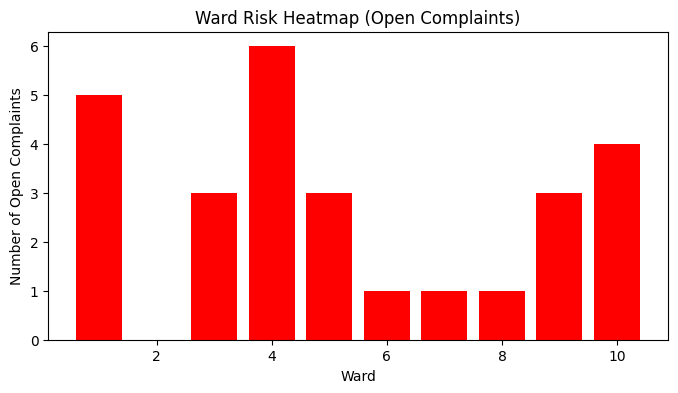

In [ ]:
# -------------------------------
# Step 5: Predictive Risk Heatmap (Ward Risk)
# -------------------------------
# Calculate ward open complaints
ward_open_complaints = complaints[complaints['Status']=='Open'].groupby('Ward')['Complaint_ID'].count()
ward_open_complaints = ward_open_complaints.reindex(wards_list, fill_value=0)

# Plot heatmap
plt.figure(figsize=(8,4))
plt.bar(ward_open_complaints.index, ward_open_complaints.values, color='red')
plt.title("Ward Risk Heatmap (Open Complaints)")
plt.xlabel("Ward")
plt.ylabel("Number of Open Complaints")
plt.show()

In [ ]:
# -------------------------------
# Step 6: Complaint Categorization
# -------------------------------
def assign_category(desc):
    for cat in categories_list:
        if cat.lower() in desc.lower():
            return cat
    return 'Other'

complaints['Category'] = complaints['Description'].apply(assign_category)
complaints[['Description','Category']].head()

,Description,Category
0,Theory require outside thought program.,Other
1,Wrong seat student a believe end.,Other
2,Certain community interesting news old coach m...,Other
3,Century discover paper heavy.,Other
4,Wide question direction center most particular...,Other


In [ ]:
# -------------------------------
# Step 7: Ward Health Score
# -------------------------------
total_complaints_per_ward = complaints.groupby('Ward')['Complaint_ID'].count()
open_complaints_per_ward = complaints[complaints['Status']=='Open'].groupby('Ward')['Complaint_ID'].count()
ward_health_score = 100 - (open_complaints_per_ward / total_complaints_per_ward * 100)
ward_health_score = ward_health_score.fillna(100)

print("Ward Health Scores:")
print(ward_health_score)

Ward Health Scores:
Ward
1       0.000000
2     100.000000
3      40.000000
4      45.454545
5      57.142857
6      66.666667
7      66.666667
8      75.000000
9      40.000000
10     20.000000
Name: Complaint_ID, dtype: float64


In [ ]:
# -------------------------------
# Step 8: Community Verification Network
# -------------------------------
verifications = pd.DataFrame({
    "Report_ID": range(1,21),
    "Verified_By": [fake.user_name() for _ in range(20)],
    "Status": [fake.random_element(elements=["verified","pending"]) for _ in range(20)]
})
verified_count = verifications[verifications['Status']=='verified'].sum()
total_reports = verifications.shape[0]
print(f"Community verified {verified_count}/{total_reports} reports")

Community verified Report_ID                                                    105
Verified_By    zfreemanamywalshdylanolsentravisowensaramartin...
Status         verifiedverifiedverifiedverifiedverifiedverifi...
dtype: object/20 reports


1️⃣ Civic Memory Engine Example:

Query: Garbage not collected in ward 2
Top 3 similar complaints:
- Dinner pull set report management reason design large never pass. (Score: 0.22)
- Consider yet suffer military during occur write manager. (Score: 0.19)
- Account though suggest participant more rich former girl wall gas south. (Score: 0.17)
Complaint is new and added to memory.

2️⃣ Contractor Reputation:
   Contractor  Reputation_Score
4  WaterWorks                 7
1    CleanPro                 6
2   LightLine                 5
3     RoadFix                 3
0   BuildFast                 2

3️⃣ Predictive Risk Heatmap:


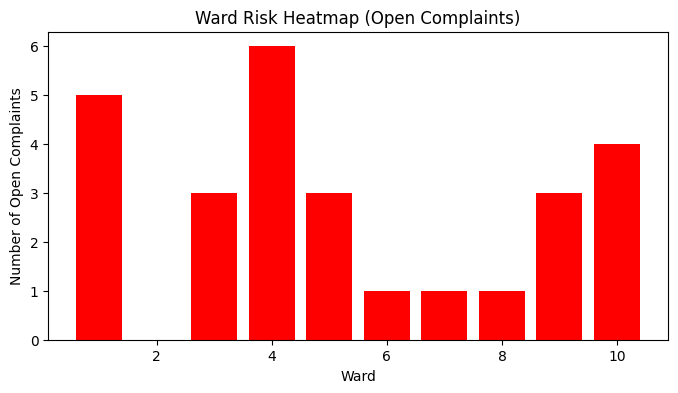


4️⃣ Complaint Categories:
                                         Description Category
0            Theory require outside thought program.    Other
1                  Wrong seat student a believe end.    Other
2  Certain community interesting news old coach m...    Other
3                      Century discover paper heavy.    Other
4  Wide question direction center most particular...    Other

5️⃣ Ward Health Scores:
Ward
1       0.000000
2     100.000000
3      40.000000
4      45.454545
5      57.142857
6      66.666667
7      66.666667
8      75.000000
9      40.000000
10     20.000000
Name: Complaint_ID, dtype: float64

6️⃣ Community Verification Network:
Verified Report_ID                                                    105
Verified_By    zfreemanamywalshdylanolsentravisowensaramartin...
Status         verifiedverifiedverifiedverifiedverifiedverifi...
dtype: object/20 reports by community


In [ ]:
# -------------------------------
# Step 9: One-Click Run Function for Hackathon Demo
# -------------------------------
def run_all_features():
    print("1️⃣ Civic Memory Engine Example:")
    find_similar_complaint("Garbage not collected in ward 2")
    is_duplicate("Garbage not collected in ward 2")

    print("\n2️⃣ Contractor Reputation:")
    print(contractor_reputation)

    print("\n3️⃣ Predictive Risk Heatmap:")
    plt.figure(figsize=(8,4))
    plt.bar(ward_open_complaints.index, ward_open_complaints.values, color='red')
    plt.title("Ward Risk Heatmap (Open Complaints)")
    plt.xlabel("Ward")
    plt.ylabel("Number of Open Complaints")
    plt.show()

    print("\n4️⃣ Complaint Categories:")
    print(complaints[['Description','Category']].head())

    print("\n5️⃣ Ward Health Scores:")
    print(ward_health_score)

    print("\n6️⃣ Community Verification Network:")
    print(f"Verified {verified_count}/{total_reports} reports by community")

# Run all features at once
run_all_features()

1️⃣ Civic Memory Engine Example:

Query: Garbage not collected in ward 2
Top 3 similar complaints:
- Dinner pull set report management reason design large never pass. (Score: 0.22)
- Consider yet suffer military during occur write manager. (Score: 0.19)
- Account though suggest participant more rich former girl wall gas south. (Score: 0.17)
Complaint is new and added to memory.

2️⃣ Contractor Reputation:
   Contractor  Reputation_Score
4  WaterWorks                 7
1    CleanPro                 6
2   LightLine                 5
3     RoadFix                 3
0   BuildFast                 2

3️⃣ Predictive Risk Heatmap:


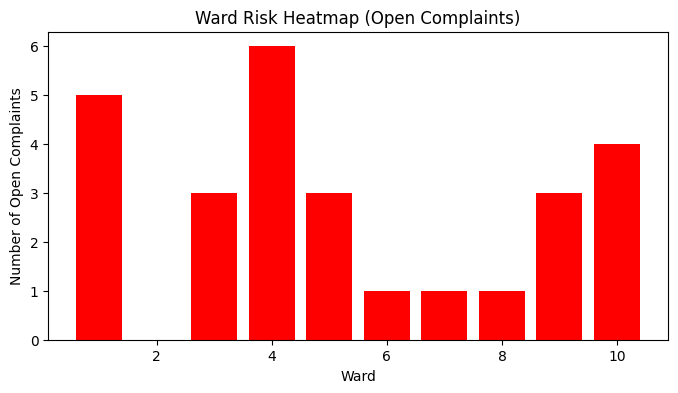


4️⃣ Complaint Categories:
                                         Description Category
0            Theory require outside thought program.    Other
1                  Wrong seat student a believe end.    Other
2  Certain community interesting news old coach m...    Other
3                      Century discover paper heavy.    Other
4  Wide question direction center most particular...    Other

5️⃣ Ward Health Scores:
Ward
1       0.000000
2     100.000000
3      40.000000
4      45.454545
5      57.142857
6      66.666667
7      66.666667
8      75.000000
9      40.000000
10     20.000000
Name: Complaint_ID, dtype: float64

6️⃣ Community Verification Network:
Verified Report_ID                                                    105
Verified_By    zfreemanamywalshdylanolsentravisowensaramartin...
Status         verifiedverifiedverifiedverifiedverifiedverifi...
dtype: object/20 reports by community


In [ ]:
run_all_features()